# Teste de treinamento de modelo para predição de Slump utilizando HGBR

In [280]:
%%capture
!pip install sklearn optuna

In [281]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

### Montagem do drive

In [282]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [283]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/slump'
filename = 'df_slump_HGBR.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Slump_mm'].copy()
df.drop(inplace=True, columns=['Slump_mm'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Agua_kg_m3                 106 non-null    float64 
 1   Metodo_Emp_Cod             106 non-null    int64   
 2   vol_ar_aprisionado         106 non-null    float64 
 3   vol_aglomerante            106 non-null    float64 
 4   vol_argamassa              106 non-null    float64 
 5   agua_equivalente_vol       106 non-null    float64 
 6   fluido_lubrificante_total  106 non-null    float64 
 7   fator_agua_finos           106 non-null    float64 
 8   bins                       106 non-null    category
 9   target                     106 non-null    int64   
dtypes: category(1), float64(7), int64(2)
memory usage: 7.7 KB


In [284]:
def split_target(df, target):
    df.drop(columns=['bins'], inplace=True, errors='ignore')
    y = df[target].copy()
    df.drop(columns=[target], inplace=True)
    return df, y

In [285]:
# Isso resulta em 70% do total para treino e 30% para teste
df_train, df_test = train_test_split(
    df, 
    test_size=0.10,
    random_state=42, 
    stratify=df['bins']
)

df_train.to_pickle(os.path.join(dirpath, 'df_train.pkl'))
df_test.to_pickle(os.path.join(dirpath, 'df_test.pkl'))

X_train, y_train = split_target(df_train, 'target')
X_test, y_test = split_target(df_test, 'target')

In [286]:
print(sum([df_train.isna().sum(), df_test.isna().sum()]))

Agua_kg_m3                   0
Metodo_Emp_Cod               0
vol_ar_aprisionado           0
vol_aglomerante              0
vol_argamassa                0
agua_equivalente_vol         0
fluido_lubrificante_total    0
fator_agua_finos             0
dtype: int64


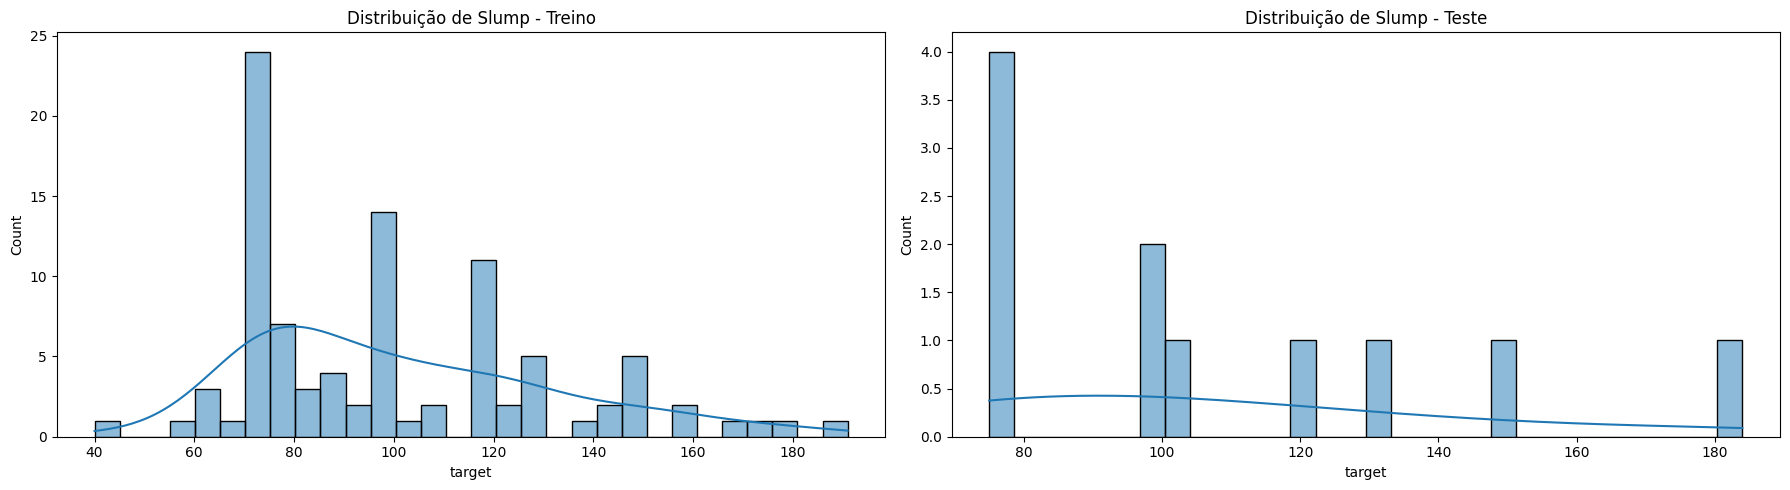

In [287]:
figure, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Slump - Treino')
sns.histplot(y_test, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Slump - Teste')
plt.tight_layout()
plt.show()

In [290]:
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}")
assert X_train.columns.equals(X_test.columns), "As colunas dos DataFrames de treino, teste e validação não são iguais."
print("X_train" + "\n" + "\n".join(f"{c}: {X_train[c].dtype} (NAs: {X_train[c].isna().sum()})" for c in X_train.columns) + "\n")
print("X_test" + "\n" + "\n".join(f"{c}: {X_test[c].dtype} (NAs: {X_test[c].isna().sum()})" for c in X_test.columns) + "\n")


X_train shape: (95, 8)
X_test shape: (11, 8)
X_train
Agua_kg_m3: float64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
vol_ar_aprisionado: float64 (NAs: 0)
vol_aglomerante: float64 (NAs: 0)
vol_argamassa: float64 (NAs: 0)
agua_equivalente_vol: float64 (NAs: 0)
fluido_lubrificante_total: float64 (NAs: 0)
fator_agua_finos: float64 (NAs: 0)

X_test
Agua_kg_m3: float64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
vol_ar_aprisionado: float64 (NAs: 0)
vol_aglomerante: float64 (NAs: 0)
vol_argamassa: float64 (NAs: 0)
agua_equivalente_vol: float64 (NAs: 0)
fluido_lubrificante_total: float64 (NAs: 0)
fator_agua_finos: float64 (NAs: 0)



In [291]:
print(f"y_train shape: {y_train.shape}\ny_test shape: {y_test.shape}\n")
print("y_train" + "\n" + f"{y_train.name}: {y_train.dtype} (NAs: {y_train.isna().sum()})" + "\n")
print("y_test" + "\n" + f"{y_test.name}: {y_test.dtype} (NAs: {y_test.isna().sum()})" + "\n")

y_train shape: (95,)
y_test shape: (11,)

y_train
target: int64 (NAs: 0)

y_test
target: int64 (NAs: 0)



In [292]:
# O Dicionário de Restrições Físicas para a Reologia (Slump)
# 1 = Positiva (Aumenta o Slump)
# -1 = Negativa (Diminui o Slump)
# 0 = Livre (Ponto ótimo ou Categórica)
regras_reologia = {
    'Agregado_Graudo_Total_kg_m3': -1,      # Mais brita = Menos slump
    'Metodo_Emp_Cod': 0,                    # Categórica = Livre
    'vol_ar_aprisionado': 1,                # Mais ar (rolamento) = Mais slump
    'vol_agregados': -1,                    # Mais esqueleto total = Menos slump
    'packing_density_proxy': 0,             # Efeito parábola (ponto ótimo de finos) = Livre
    'indice_lubrificacao_global_vol': 1,    # Mais química/água = Mais slump
    'fluido_lubrificante_total': 1,         # Mais fluido base = Mais slump
    'fator_agua_finos_reverso': 1,          # Pasta mais molhada = Mais slump
    'lubrificacao_efetiva': 1               # Lubrificação sem segregação = Mais slump
}

# Criando a tupla de restrições na exata ordem do X_train
# O HGBR exige que as restrições sejam passadas como uma lista/tupla com a mesma quantidade de features
restricoes_hgbr = tuple(regras_reologia[col] for col in regras_reologia)

# 2. Gere a lista com 21 zeros automaticamente
restricoes_completas = [0] * len(X_train.columns)

# 3. Preencha os valores corretos baseando-se no nome da coluna
for i, coluna in enumerate(X_train.columns):
    if coluna in regras_reologia:
        restricoes_completas[i] = regras_reologia[coluna]
        print(f"Coluna '{coluna}' mapeada para restrição {regras_reologia[coluna] if coluna in regras_reologia else 0}.")

print("Lista de restrições de tamanho 9 gerada com sucesso:")
print(restricoes_completas)

hyper_params = {
    "max_bins": 32,                # Força o agrupamento em nano-datasets
    "max_depth": 2,                # Profundidade
    "min_samples_leaf": 5,         # Controla o tamanho mínimo das folhas (regularização estrutural)
    "learning_rate": 0.03,
    "max_iter": 45,               # Equivalente ao n_estimators
    "l2_regularization": 5.0,     # Ridge penalty (L2)
    "random_state": 42,
    "early_stopping": True,      # OBRIGA o modelo a monitorar a validação
    "validation_fraction": 0.10, # Separa 10% do X_train internamente para gerar a linha de validação
    "n_iter_no_change": 10,     # Paciência de 10 iterações para o early stopping
    "verbose": False
}

Coluna 'Metodo_Emp_Cod' mapeada para restrição 0.
Coluna 'vol_ar_aprisionado' mapeada para restrição 1.
Coluna 'fluido_lubrificante_total' mapeada para restrição 1.
Lista de restrições de tamanho 9 gerada com sucesso:
[0, 0, 1, 0, 0, 0, 1, 0]


In [293]:
X_train.columns

Index(['Agua_kg_m3', 'Metodo_Emp_Cod', 'vol_ar_aprisionado', 'vol_aglomerante',
       'vol_argamassa', 'agua_equivalente_vol', 'fluido_lubrificante_total',
       'fator_agua_finos'],
      dtype='object')

In [294]:
model = HistGradientBoostingRegressor(**hyper_params)

In [295]:
%%time
model.fit(X_train, y_train)

CPU times: user 35.4 ms, sys: 1.9 ms, total: 37.3 ms
Wall time: 40.5 ms


HistGradientBoostingRegressor(early_stopping=True, l2_regularization=5.0,
                              learning_rate=0.03, max_bins=32, max_depth=2,
                              max_iter=45, min_samples_leaf=5, random_state=42,
                              verbose=False)

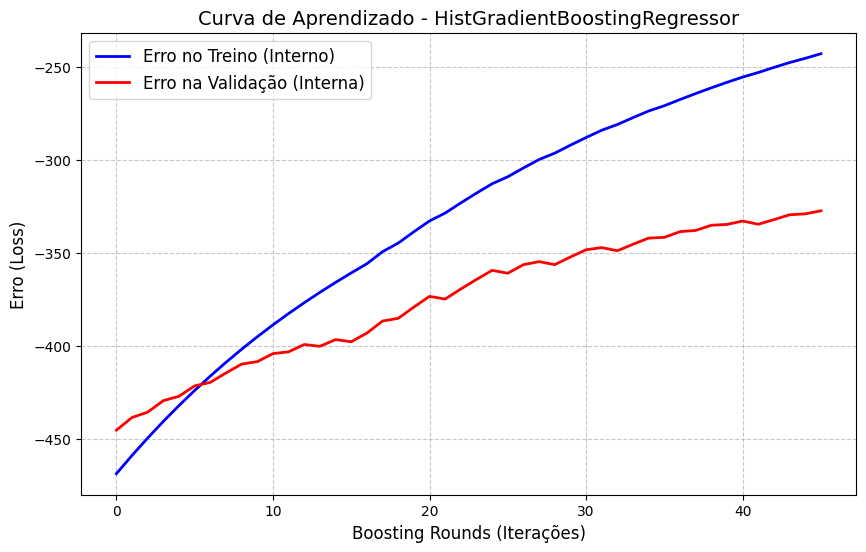

In [296]:
# 3. Extraindo os históricos gravados dentro do modelo
train_rmse = model.train_score_
val_rmse = model.validation_score_
treino_historico = model.train_score_
val_historico = model.validation_score_

# 4. Plotando o Gráfico
plt.figure(figsize=(10, 6))
plt.plot(treino_historico, label='Erro no Treino (Interno)', color='blue', linewidth=2)
plt.plot(val_historico, label='Erro na Validação (Interna)', color='red', linewidth=2)

plt.title('Curva de Aprendizado - HistGradientBoostingRegressor', fontsize=14)
plt.xlabel('Boosting Rounds (Iterações)', fontsize=12)
plt.ylabel('Erro (Loss)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [297]:
# Estatísticas finais
train_final = train_rmse[-1]
val_final = val_rmse[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      -242.894761
⚠️  RMSE Validação (final):   -327.302245
📈 Gap (Val - Train):        -84.407484


In [298]:
# Fazer predições no conjunto de teste
y_pred = model.predict(X_test)
debug_df = X_test.copy()

debug_df["pred"] = y_pred
debug_df["ground_truth"] = y_test
debug_df["residual"] = debug_df["ground_truth"] - debug_df["pred"]

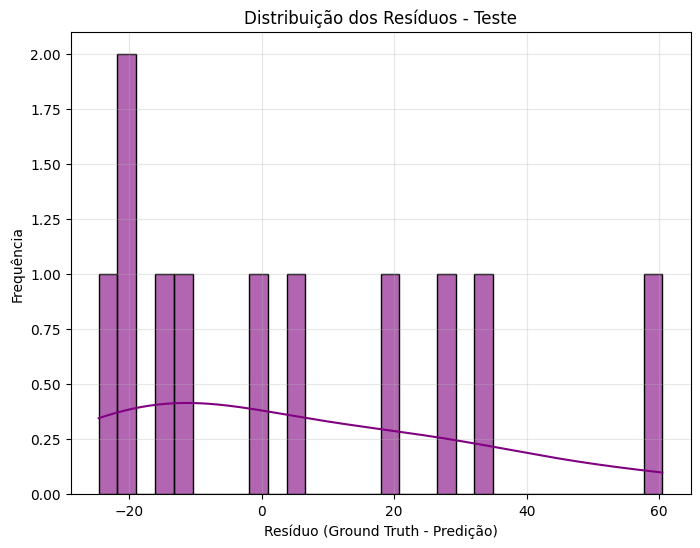

In [299]:
plt.figure(figsize=(8, 6))
sns.histplot(debug_df["residual"], bins=30, kde=True, color='purple', alpha=0.6)
plt.title("Distribuição dos Resíduos - Teste")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

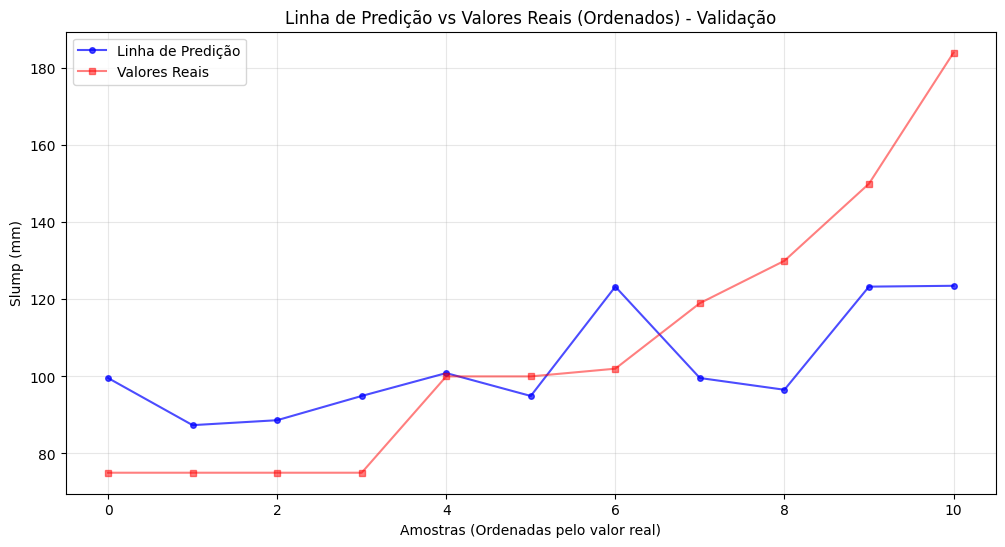

In [300]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Validação")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [301]:
r2 = r2_score(debug_df["ground_truth"], debug_df["pred"])
rmse = root_mean_squared_error(debug_df["ground_truth"], debug_df["pred"])
mae = mean_absolute_error(debug_df["ground_truth"], debug_df["pred"])
mape = mean_absolute_percentage_error(debug_df["ground_truth"], debug_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 26.4371
mean_absolute_error: 21.6175
mean_absolute_percentage_error: 0.1941
R² Score: 39.2923


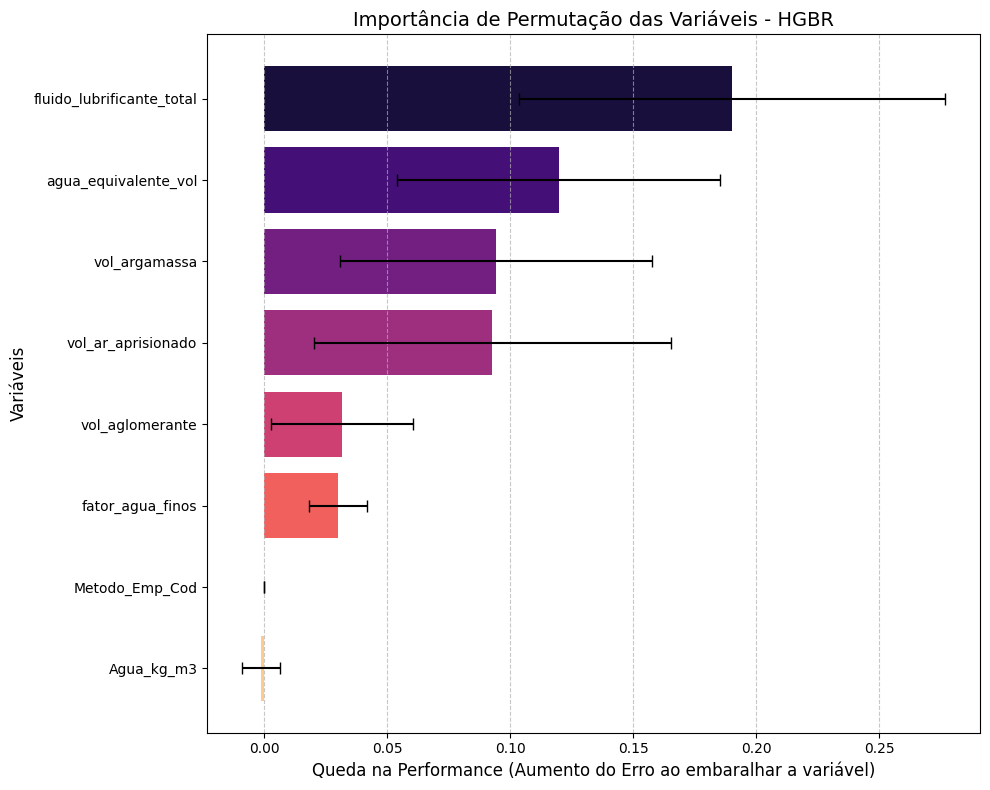

In [302]:
# Isso mostra quais features realmente importam para prever dados NOVOS, e não apenas o que ele decorou.
resultado_permutacao = permutation_importance(
    model, X_test, y_test, 
    n_repeats=10,        # Ele vai embaralhar cada coluna 10 vezes para tirar uma média segura
    random_state=42, 
    n_jobs=-1            # Usa todos os núcleos do seu processador
)

# 2. Criando um DataFrame com os resultados
df_importancia_hgbr = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia_Media': resultado_permutacao.importances_mean,
    'Desvio_Padrao': resultado_permutacao.importances_std
})

# Ordenando da mais importante para a menos importante
df_importancia_hgbr = df_importancia_hgbr.sort_values(by='Importancia_Media', ascending=False)

# 3. Plotando o Gráfico (Solução sem o bug do Seaborn)
plt.figure(figsize=(10, 8))

# Extraindo a paleta de cores do Seaborn para manter o estilo
cores = sns.color_palette('magma', n_colors=len(df_importancia_hgbr))

# Usando o barh (Bar Horizontal) nativo do Matplotlib, que aceita o xerr perfeitamente
plt.barh(
    y=df_importancia_hgbr['Feature'], 
    width=df_importancia_hgbr['Importancia_Media'],
    xerr=df_importancia_hgbr['Desvio_Padrao'], 
    color=cores,
    capsize=4,        # Coloca aqueles "tracinhos" verticais na ponta da barra de erro
    edgecolor='none'
)

# Invertemos o eixo Y para a feature mais importante ficar no topo
plt.gca().invert_yaxis()

plt.title('Importância de Permutação das Variáveis - HGBR', fontsize=14)
plt.xlabel('Queda na Performance (Aumento do Erro ao embaralhar a variável)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()